In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("students_2022.csv")
print(df.head())

       dni_hash      tit_hash      asi_hash  anyo_ingreso tipo_ingreso  \
0  0002ccc8623e  ec2e990b934d  3cf72f968b84        2021.0          BMA   
1  00075bbc7af3  bb668ca95563  dad11be29e74        2022.0          NCA   
2  0008337bd791  1d0ebea552eb  007015a20672        2020.0          NAP   
3  000be0ddb26c  d6a403173361  39e5b4830d4d        2022.0          NAP   
4  000d5aac651d  0fecf9247f3d  a5196fecd052        2019.0          NAP   

   nota10_hash  nota14_hash       campus_hash estudios_p_hash estudios_m_hash  \
0      7.13600     7.136000  79df3742da86cfd4               T               T   
1      7.50541    10.078002  6781b441c78d2643               R               R   
2      8.10500    11.108000  6781b441c78d2643               L               F   
3      6.30900     8.792000  f01a95a004153cb8               L               T   
4      6.28000     8.530000  8138689887e6817e               F               F   

   ... pft_events_2023_7 pft_days_logged_2023_7 pft_visits_2023_7  \

In [16]:
print(df.isna().sum())

dni_hash                    0
tit_hash                    0
asi_hash                    0
anyo_ingreso                0
tipo_ingreso                0
                           ..
pft_total_minutes_2023_7    0
n_wifi_days_2023_7          0
resource_events_2023_7      0
n_resource_days_2023_7      0
n_courses                   0
Length: 170, dtype: int64


In [17]:
df = df.fillna(df.mean(numeric_only=True))
df = df.fillna("Unknown")
print(df.isna().sum())

dni_hash                    0
tit_hash                    0
asi_hash                    0
anyo_ingreso                0
tipo_ingreso                0
                           ..
pft_total_minutes_2023_7    0
n_wifi_days_2023_7          0
resource_events_2023_7      0
n_resource_days_2023_7      0
n_courses                   0
Length: 170, dtype: int64


In [18]:
cols_to_drop = ['dni_hash', 'tit_hash', 'asi_hash', 'baja_fecha', 'caca', 'fecha_datos', 'activ1']

#dni_hash -> student id
#tit_hash -> degree identifier
#asi-hash -> course identifier

#we drop these because they are unique categorical identifiers 

#baja_fecha -> cancellation date

#we drop this because machine learning model because
# it is the same as dropping out

#caca -> year of enrollment
#fecha_datos -> date of data export

#we drop this because not relevant

df=df.drop(columns=cols_to_drop)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes + 1
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df = df.drop(columns=constant_cols)

print(df.head())

   anyo_ingreso  tipo_ingreso  nota10_hash  nota14_hash  campus_hash  \
0        2021.0             2      7.13600     7.136000           21   
1        2022.0             5      7.50541    10.078002           20   
2        2020.0             4      8.10500    11.108000           20   
3        2022.0             4      6.30900     8.792000           37   
4        2019.0             4      6.28000     8.530000           23   

   estudios_p_hash  estudios_m_hash  dedicacion  desplazado_hash  \
0                6                6           1                1   
1                5                5           1                2   
2                2                1           1                2   
3                2                6           1                1   
4                1                1           1                1   

   abandono_hash  ...  pft_events_2023_7  pft_days_logged_2023_7  \
0              2  ...                0.0                     0.0   
1              2  ... 

In [19]:
corr=df.corr()["abandono_hash"].sort_values(ascending=False).drop("abandono_hash")
print(corr)

matricula_activa               0.346569
rendimiento_total              0.323977
rendimiento_cuat_b             0.316380
cred_sup_normal                0.235223
cred_sup_total                 0.230987
                                 ...   
pft_test_submissions_2023_1   -0.054763
cred_pend_sup_tit             -0.055522
cred_mat1                     -0.074140
dedicacion                    -0.093341
cred_ptes_acta                -0.113014
Name: abandono_hash, Length: 155, dtype: float64


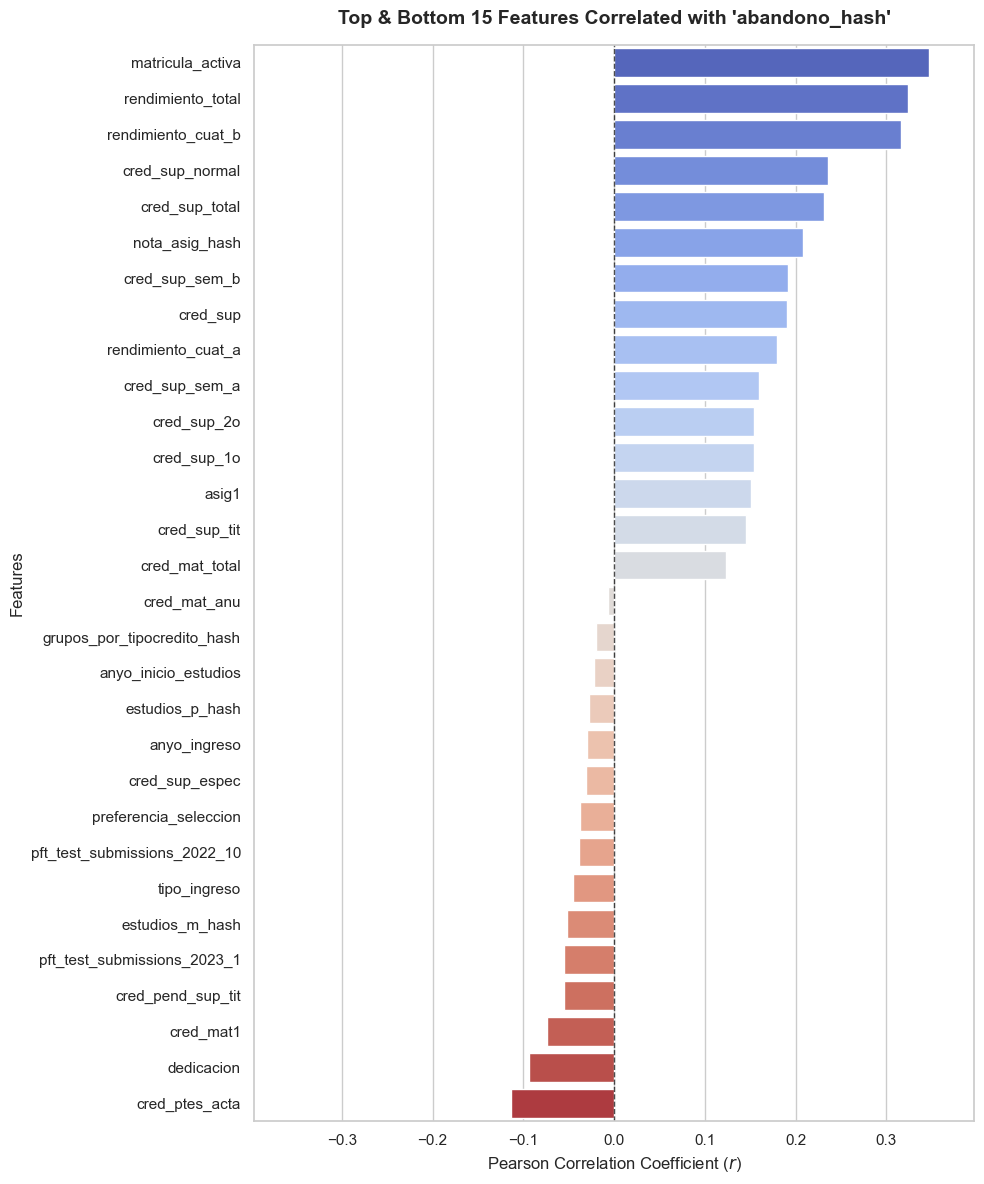

In [20]:
# 1. Filter for the top 15 and bottom 15 correlations
# We concatenate them and drop duplicate indices in case there are fewer than 30 features total
corr_filtered = pd.concat([corr.head(15), corr.tail(15)])
corr_filtered = corr_filtered[~corr_filtered.index.duplicated()]

# 2. Set a clean, modern style
sns.set_theme(style="whitegrid")

# 3. Define figure size dynamically based on the number of filtered features
fig, ax = plt.subplots(figsize=(10, max(6, len(corr_filtered) * 0.4)))

# 4. Create the horizontal bar plot
# 'coolwarm' maps negative correlations to blue and positive to red
sns.barplot(
    x=corr_filtered.values, 
    y=corr_filtered.index, 
    hue=corr_filtered.index,
    legend=False,
    palette="coolwarm", 
    ax=ax
)

# 5. Add a vertical reference line at 0
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)

# 6. Customize titles and axis labels
ax.set_title("Top & Bottom 15 Features Correlated with 'abandono_hash'", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Pearson Correlation Coefficient ($r$)", fontsize=12)
ax.set_ylabel("Features", fontsize=12)

# 7. Center the x-axis limits around 0 for symmetry
max_val = max(abs(corr_filtered.min()), abs(corr_filtered.max()))
ax.set_xlim(-max_val - 0.05, max_val + 0.05)

# Adjust layout to prevent text clipping
plt.tight_layout()

# 8. Show or save the plot
plt.show()
# plt.savefig('top_bottom_correlations.png', dpi=300)

**Socio - economic and demographic background**

- estudios_p_hash—Hash code referring to the father’s education level; 

- estudios_m_hash—Hash code referring to the mother’s education level; 

- dedicacion—Student’s dedication to university studies; 

- desplazado—Whether the student had to move provinces to attend university. 

Out of this category, **dedication** came up the **most correlated**.

dedicacion
1    193.107100
2    178.655462
Name: abandono_hash, dtype: float64


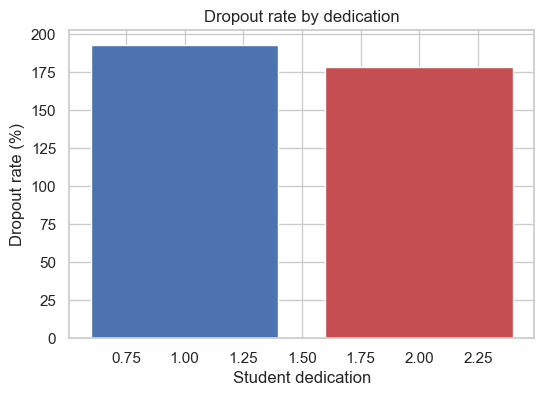

In [21]:
#grouping by dedication and calculating the average dropout rate
dedication_analysis = df.groupby('dedicacion')['abandono_hash'].mean() * 100

print(dedication_analysis)

#creating a bar plot to compare dropout rates by dedication
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dedication_analysis.index, dedication_analysis.values, color=["#4C72B0", "#C44E52"])
ax.set_title("Dropout rate by dedication")
ax.set_ylabel("Dropout rate (%)")
ax.set_xlabel("Student dedication")
plt.show()